# **CÀI ĐẶT THƯ VIỆN**

In [ ]:
!pip install yfinance pyswarms tensorflow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import pyswarms as ps
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
import yfinance as yf
from datetime import datetime
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
warnings.filterwarnings('ignore')

Thư viện đã được nhập thành công.


# **GET THE DATASET**

In [ ]:
ticker_gold = "GC=F"
df_gold_raw = yf.download(ticker_gold, start="2005-01-01", progress=False, auto_adjust=True)

# Tải các biến ngoại sinh
exog_tickers = ['DX-Y.NYB', 'CL=F', '^GSPC', '^TNX']
exog_data_raw = yf.download(exog_tickers, start="2005-01-01", progress=False, auto_adjust=True)

# Xử lý MultiIndex: Trích xuất Close và Volume
if isinstance(df_gold_raw.columns, pd.MultiIndex):
    gold_close = df_gold_raw['Close'][ticker_gold].to_frame(name="Gold_Close")
    gold_vol = df_gold_raw['Volume'][ticker_gold].to_frame(name="Gold_Volume")
else:
    gold_close = df_gold_raw['Close'].to_frame(name="Gold_Close")
    gold_vol = df_gold_raw['Volume'].to_frame(name="Gold_Volume")

if isinstance(exog_data_raw.columns, pd.MultiIndex):
    exog_close = exog_data_raw['Close']
    name_map = {'DX-Y.NYB': 'DXY', 'CL=F': 'Oil', '^GSPC': 'SP500', '^TNX': 'Bond_10Y'}
    exog_close = exog_close.rename(columns=name_map)
else:
    exog_close = exog_data_raw['Close']


,Date,Gold_Close,Oil,DXY,SP500,Bond_10Y,Gold_Volume
2833,2026-04-06,4656.799805,112.410004,99.980003,6611.830078,4.335,148.0
2834,2026-04-07,4657.100098,112.949997,99.639999,6616.850098,4.343,327.0
2835,2026-04-08,4749.500000,94.410004,99.129997,6782.810059,4.291,405.0
2836,2026-04-09,4792.200195,97.870003,98.820000,6824.660156,4.293,1277.0
2837,2026-04-10,4761.899902,96.570000,98.650002,6816.890137,4.317,1277.0


Tổng mẫu dữ liệu: 2838


In [ ]:
df = pd.concat([gold_close, exog_close, gold_vol], axis=1)
df = df.ffill().dropna()
df = df.reset_index().rename(columns={'index': 'Date'})
display(df.tail())
print(f"Tổng mẫu dữ liệu: {len(df)}")
df.to_csv("gia_vang_benchmark.csv", index=False, encoding='utf-8-sig')
print(f"Đã tải xong {len(df)} ngày dữ liệu benchmark (2015-01-01 → {df['Date'].iloc[-1].date()})")
print("Các cột:", df.columns.tolist())

IndexError: single positional indexer is out-of-bounds

In [ ]:
df

           Date   Gold_Close        DXY         Oil        SP500  Bond_Yield  \
0    2015-01-02  1186.000000  91.080002   52.689999  2058.199951       2.123   
1    2015-01-05  1203.900024  91.379997   50.040001  2020.579956       2.039   
2    2015-01-06  1219.300049  91.500000   47.930000  2002.609985       1.963   
3    2015-01-07  1210.599976  91.889999   48.650002  2025.900024       1.954   
4    2015-01-08  1208.400024  92.370003   48.790001  2062.139893       2.016   
...         ...          ...        ...         ...          ...         ...   
2833 2026-04-06  4656.799805  99.980003  112.410004  6611.830078       4.335   
2834 2026-04-07  4657.100098  99.639999  112.949997  6616.850098       4.343   
2835 2026-04-08  4749.500000  99.129997   94.410004  6782.810059       4.291   
2836 2026-04-09  4792.200195  98.820000   97.870003  6824.660156       4.293   
2837 2026-04-10  4761.899902  98.650002   96.570000  6816.890137       4.317   

      Gold_Volume  
0           138.0  

# Chuẩn bị dữ liệu & Hàm tạo dataset

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def create_multivariate_dataset(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), :])
        y.append(data[i + look_back, 0]) # Cột 0 là Gold_Close
    return np.array(X), np.array(y)

def calculate_directional_accuracy(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    return np.mean((true_diff > 0) == (pred_diff > 0)) * 100

# Khởi tạo tham số
feature_cols = ['Gold_Close', 'DXY', 'Oil', 'SP500', 'Bond_10Y', 'Gold_Volume']
num_features = len(feature_cols)

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[feature_cols])

scaler_gold = MinMaxScaler(feature_range=(0, 1))
scaler_gold.fit(df[['Gold_Close']])

# Chia 70/20/10
total_len = len(scaled_data)
train_end = int(total_len * 0.70)
val_end   = int(total_len * 0.90)

train_data = scaled_data[:train_end]
val_data   = scaled_data[train_end:val_end]
test_data  = scaled_data[val_end:]

print(f"Train size: {len(train_data)}, Val size: {len(val_data)}, Test size: {len(test_data)}")

Train size: 1986, Val size: 568, Test size: 284


# **CORRELATION MATRIX HEATMAP**

## Biểu diễn ma trận tương quan

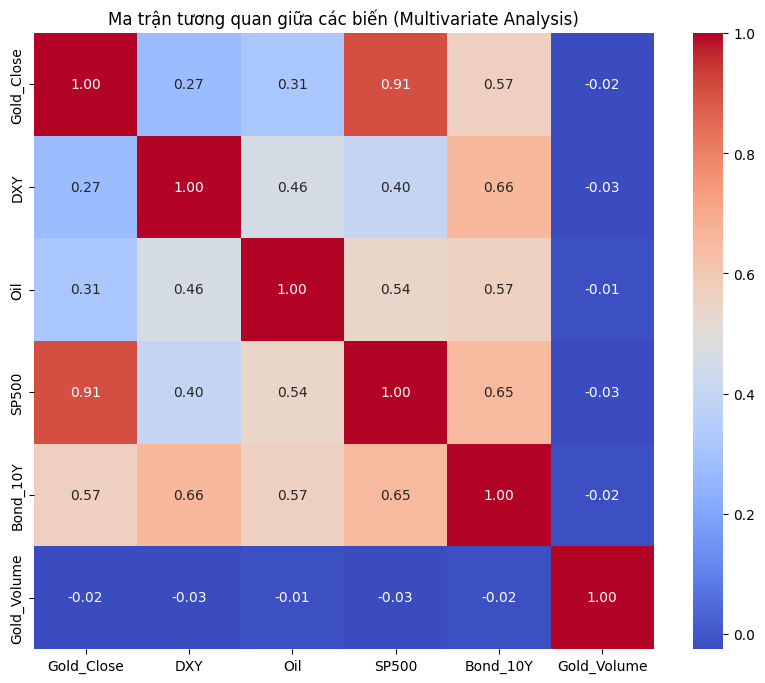

Mức độ tương quan với giá Vàng:
Gold_Close     1.000000
SP500          0.906599
Bond_10Y       0.567626
Oil            0.312195
DXY            0.274848
Gold_Volume   -0.024419
Name: Gold_Close, dtype: float64


In [ ]:
# Tính ma trận tương quan
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến (Multivariate Analysis)')
plt.show()

print("Mức độ tương quan với giá Vàng:")
print(corr_matrix['Gold_Close'].sort_values(ascending=False))

# **PSO-LSTM**

## Hàm mục tiêu cho PSO

In [ ]:
def objective_function_optimized(x):
    fitness = []
    # EarlyStopping giúp tránh Overfitting theo Nagata (2024)
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    for particle in x:
        look_back    = max(10, min(60, int(particle[0])))
        hidden_units = max(32, min(128, int(particle[1])))
        lr           = max(0.0001, min(0.01, particle[2]))
        batch_size   = max(16, min(64, int(particle[3])))
        num_layers   = max(1, min(2, int(particle[4])))
        dropout      = max(0.0, min(0.3, particle[5]))

        try:
            X_train, y_train = create_multivariate_dataset(train_data, look_back)
            X_val,   y_val   = create_multivariate_dataset(val_data, look_back)

            model = Sequential()
            for i in range(num_layers):
                return_seq = (i < num_layers - 1)
                if i == 0:
                    model.add(LSTM(hidden_units, return_sequences=return_seq, input_shape=(look_back, num_features)))
                else:
                    model.add(LSTM(hidden_units, return_sequences=return_seq))
                model.add(Dropout(dropout))
            model.add(Dense(1))
            model.compile(optimizer=Adam(learning_rate=lr), loss='mse')

            model.fit(X_train, y_train, epochs=10, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)

            pred_scaled = model.predict(X_val, verbose=0)
            # Tính Fitness trên tập Validation
            rmse = np.sqrt(mean_squared_error(y_val, pred_scaled))
            fitness.append(rmse)
        except:
            fitness.append(1e6)
    return np.array(fitness)

## Chạy PSO tối ưu siêu tham số

In [ ]:
# Chạy PSO tối ưu hóa siêu tham số
print("Đang thực hiện tối ưu hóa PSO cho mô hình Multivariate LSTM...")
bounds = ([10, 32, 0.0001, 16, 1, 0.0], [60, 128, 0.01, 64, 2, 0.3])
options = {'c1': 2.0, 'c2': 2.0, 'w': 0.9}

optimizer = ps.single.GlobalBestPSO(n_particles=10, dimensions=6, options=options, bounds=bounds)
cost, pos = optimizer.optimize(objective_function_optimized, iters=15)

print(f"\nSiêu tham số tốt nhất từ PSO:")
print(f"Look-back: {int(pos[0])}, Units: {int(pos[1])}, LR: {pos[2]:.5f}, Batch: {int(pos[3])}, Layers: {int(pos[4])}, Dropout: {pos[5]:.2f}")

2026-04-11 12:55:41,033 - pyswarms.single.global_best - INFO - Optimize for 15 iters with {'c1': 2.0, 'c2': 2.0, 'w': 0.9}


Đang thực hiện tối ưu hóa PSO cho mô hình Multivariate LSTM...


pyswarms.single.global_best: 100%|██████████|15/15, best_cost=0.00845
2026-04-11 13:06:10,833 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.008447408488446509, best pos: [1.84829387e+01 9.11885638e+01 3.24427155e-03 1.88006374e+01
 1.50322853e+00 1.36006474e-01]



Siêu tham số tốt nhất từ PSO:
Look-back: 18, Units: 91, LR: 0.00324, Batch: 18, Layers: 1, Dropout: 0.14


## Huấn luyện mô hình cuối cùng & Đánh giá

In [ ]:
# ====================== HUဢN LUYሂN FINAL MODEL (theo best PSO) ======================
best_look_back = int(pos[0])
best_units     = int(pos[1])
best_lr        = float(pos[2])
best_batch     = int(pos[3])
best_layers    = int(pos[4])
best_dropout   = float(pos[5])

# Tạo dataset cuối cùng
X_all, y_all = create_multivariate_dataset(scaled_data, best_look_back)
train_size = int(len(X_all) * 0.8)

X_train, y_train = X_all[:train_size], y_all[:train_size]
X_test,  y_test  = X_all[train_size:], y_all[train_size:]

# Xây dựng mô hình cuối cùng
final_model = Sequential()
for i in range(best_layers):
    return_seq = (i < best_layers - 1)
    if i == 0:
        final_model.add(LSTM(best_units, return_sequences=return_seq,
                            input_shape=(best_look_back, num_features)))
    else:
        final_model.add(LSTM(best_units, return_sequences=return_seq))
    final_model.add(Dropout(best_dropout))

final_model.add(Dense(1))
final_model.compile(optimizer=Adam(learning_rate=best_lr), loss='mse')

# EarlyStopping theo các paper
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

print("Huấn luyện Final PSO-LSTM model vối best parameters...")
history = final_model.fit(X_train, y_train,
                          epochs=100,
                          batch_size=best_batch,
                          validation_split=0.15,
                          callbacks=[early_stop],
                          verbose=1)

Huấn luyện Final PSO-LSTM model vối best parameters...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0021 - val_loss: 0.0061
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.7755e-04 - val_loss: 0.0030
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8527e-04 - val_loss: 8.4968e-04
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2149e-04 - val_loss: 0.0014
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1244e-04 - val_loss: 2.2083e-04
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.4541e-05 - val_loss: 1.2242e-04
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.7105e-05 - val_loss: 1.8802e-04
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.6854e-05 - val_loss: 4.4727e-05
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.0635e-05 - val_loss: 5.6263e-05
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.2643e-05 - val_loss: 4.1807e-05
Epoch 11/1

Đánh giá và dự đoán

In [ ]:
# Dự đoán
pred_scaled = final_model.predict(X_test, verbose=0)
pred = scaler_gold.inverse_transform(pred_scaled)
y_true = scaler_gold.inverse_transform(y_test.reshape(-1, 1))

# Metrics PSO-LSTM
mae   = mean_absolute_error(y_true, pred)
rmse  = np.sqrt(mean_squared_error(y_true, pred))
mape  = mean_absolute_percentage_error(y_true, pred) * 100
r2    = r2_score(y_true, pred)
dir_acc = calculate_directional_accuracy(y_true.flatten(), pred.flatten())

print("\n" + "="*80)
print("KẾT QUẢ PSO-LSTM MULTIVARIATE (TỐI ƯU THEO CÁC NGHIÊN CỨU)")
print("="*80)
print(f"MAE                  : {mae:.2f} USD")
print(f"RMSE                 : {rmse:.2f} USD")
print(f"MAPE                 : {mape:.2f}%")
print(f"R²                   : {r2:.4f}")
print(f"Directional Accuracy : {dir_acc:.2f}%")
print("="*80)


KẾT QUẢ PSO-LSTM MULTIVARIATE (TỐI ƯU THEO CÁC NGHIÊN CỨU)
MAE                  : 74.21 USD
RMSE                 : 114.36 USD
MAPE                 : 2.13%
R²                   : 0.9823
Directional Accuracy : 53.83%


## Vẽ biểu đồ dự đoán

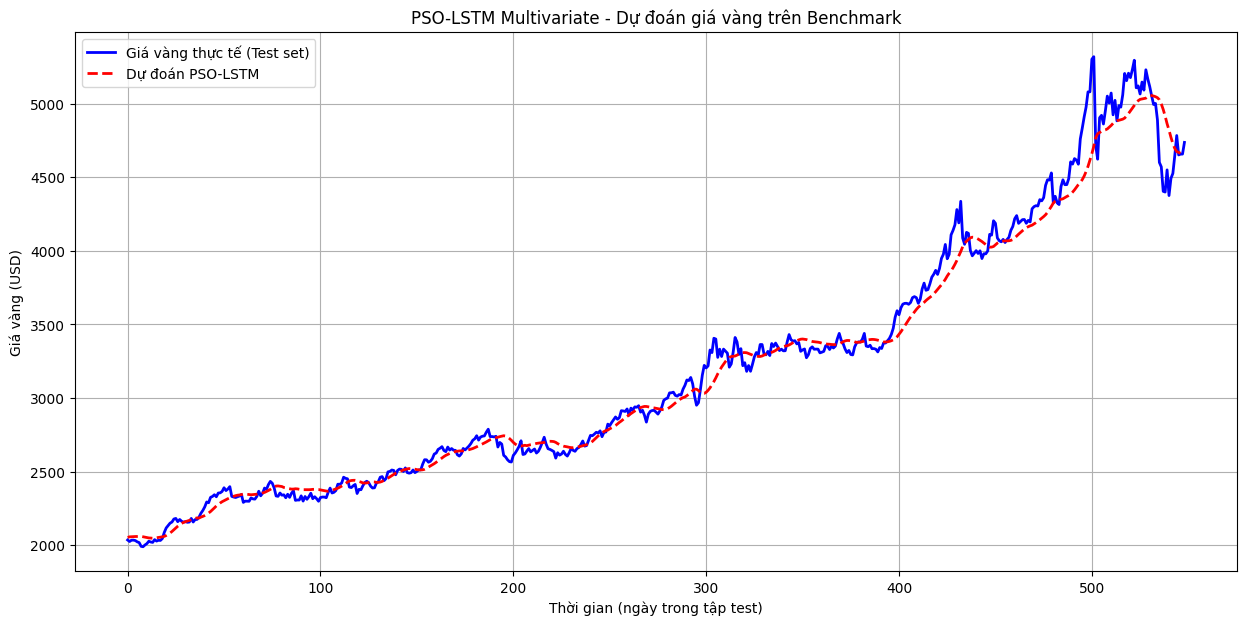

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(y_true, label='Giá vàng thực tế (Test set)', color='blue', linewidth=2)
plt.plot(pred, label='Dự đoán PSO-LSTM', color='red', linestyle='--', linewidth=2)
plt.title('PSO-LSTM Multivariate - Dự đoán giá vàng trên Benchmark')
plt.xlabel('Thời gian (ngày trong tập test)')
plt.ylabel('Giá vàng (USD)')
plt.legend()
plt.grid(True)
plt.show()

Tải model

In [ ]:
import joblib
import json
from datetime import datetime

# Lưu mô hình Keras
final_model.save('model_PSO_LSTM_final.h5')
print("Đã lưu model: model_PSO_LSTM_final.h5")

# Lưu Scaler
joblib.dump(scaler_gold, 'scaler_gold.pkl')
print("Đã lưu scaler: scaler_gold.pkl")

# Lưu Best Parameters từ PSO
best_params = {
    "look_back": int(pos[0]),
    "hidden_units": int(pos[1]),
    "learning_rate": float(pos[2]),
    "batch_size": int(pos[3]),
    "num_layers": int(pos[4]),
    "dropout_rate": float(pos[5]),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open('best_params.json', 'w') as f:
    json.dump(best_params, f, indent=4)
print("Đã lưu best parameters: best_params.json")

# Lưu Metrics đánh giá
metrics = {
    "MAE": float(mae),
    "RMSE": float(rmse),
    "MAPE": float(mape),
    "R2": float(r2),
    "Directional_Accuracy": float(dir_acc),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("Đã lưu metrics: model_metrics.json")

print("\nLƯU TRỮ HOÀN TẤT!")
print("Các file đã được lưu:")
print("   • model_PSO_LSTM_final.h5")
print("   • scaler_gold.pkl")
print("   • best_params.json")
print("   • model_metrics.json")

2026-04-11 13:11:57,197 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


Đã lưu model: model_PSO_LSTM_final.h5
Đã lưu scaler: scaler_gold.pkl
Đã lưu best parameters: best_params.json
Đã lưu metrics: model_metrics.json

LƯU TRỮ HOÀN TẤT!
Các file đã được lưu:
   • model_PSO_LSTM_final.h5
   • scaler_gold.pkl
   • best_params.json
   • model_metrics.json


# **LSTM BASELINE**

## Xây dựng & Huấn luyện LSTM Baseline

In [ ]:
# Tham số cố định hợp lý cho Baseline (theo chuẩn thực nghiệm)
baseline_look_back = 60
baseline_units     = 128
baseline_layers    = 2
baseline_lr        = 0.001
baseline_dropout   = 0.2
baseline_batch     = 32
baseline_epochs    = 60

# Tạo dataset với look_back cố định cho Baseline
X_all_base, y_all_base = create_multivariate_dataset(scaled_data, baseline_look_back)
train_size_base = int(len(X_all_base) * 0.8)

X_train_base = X_all_base[:train_size_base]
y_train_base = y_all_base[:train_size_base]
X_test_base  = X_all_base[train_size_base:]
y_test_base  = y_all_base[train_size_base:]

# Xây dựng mô hình Baseline
baseline_model = Sequential()
for i in range(baseline_layers):
    return_seq = (i < baseline_layers - 1)
    if i == 0:
        baseline_model.add(LSTM(baseline_units, return_sequences=return_seq,
                               input_shape=(baseline_look_back, num_features)))
    else:
        baseline_model.add(LSTM(baseline_units, return_sequences=return_seq))
    baseline_model.add(Dropout(baseline_dropout))

baseline_model.add(Dense(1))
baseline_model.compile(optimizer=Adam(learning_rate=baseline_lr), loss='mse')

print("Đang huấn luyện LSTM Baseline...")
baseline_model.fit(X_train_base, y_train_base,
                   epochs=baseline_epochs,
                   batch_size=baseline_batch,
                   validation_split=0.1,
                   verbose=1)
print("Huấn luyện Baseline hoàn tất!")

Đang huấn luyện LSTM Baseline...
Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0024 - val_loss: 0.0013
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.7424e-04 - val_loss: 1.4499e-04
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.3685e-04 - val_loss: 6.9886e-04
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1989e-04 - val_loss: 1.4076e-04
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9110e-04 - val_loss: 1.1116e-04
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.5625e-04 - val_loss: 2.5854e-04
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.5686e-04 - val_loss: 9.0390e-05
Epoch 8/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6420e-04 - val_loss: 1.3646e-04
Epoch 9/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3903e-04 - val_loss: 8.0799e-05
Epoch 10/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1994e-04 - val_loss: 8.8523e-05
Epoch 11/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10

## Đánh giá & Bảng so sánh PSO-LSTM vs LSTM Baseline

In [ ]:
# ====================== DỰ ĐOÁN VÀ ĐÁNH GIÁ PSO-LSTM ======================
pred_scaled = final_model.predict(X_test, verbose=0)
pred = scaler_gold.inverse_transform(pred_scaled)
y_true = scaler_gold.inverse_transform(y_test.reshape(-1, 1))

mae   = mean_absolute_error(y_true, pred)
rmse  = np.sqrt(mean_squared_error(y_true, pred))
mape  = mean_absolute_percentage_error(y_true, pred) * 100
r2    = r2_score(y_true, pred)
dir_acc = calculate_directional_accuracy(y_true.flatten(), pred.flatten())

# ====================== DỰ ĐOÁN VÀ ĐÁNH GIÁ BASELINE ======================
pred_base_scaled = baseline_model.predict(X_test_base, verbose=0)
pred_base = scaler_gold.inverse_transform(pred_base_scaled)
y_true_base = scaler_gold.inverse_transform(y_test_base.reshape(-1, 1))

mae_base   = mean_absolute_error(y_true_base, pred_base)
rmse_base  = np.sqrt(mean_squared_error(y_true_base, pred_base))
mape_base  = mean_absolute_percentage_error(y_true_base, pred_base) * 100
r2_base    = r2_score(y_true_base, pred_base)
dir_acc_base = calculate_directional_accuracy(y_true_base.flatten(), pred_base.flatten())

# ====================== BẢNG SO SÁNH ======================
comparison = pd.DataFrame({
    "Metric": ["MAE (USD)", "RMSE (USD)", "MAPE (%)", "R²", "Directional Accuracy (%)"],
    "PSO-LSTM (Proposal)": [f"{mae:.2f}", f"{rmse:.2f}", f"{mape:.2f}", f"{r2:.4f}", f"{dir_acc:.2f}"],
    "LSTM Baseline": [f"{mae_base:.2f}", f"{rmse_base:.2f}", f"{mape_base:.2f}",
                      f"{r2_base:.4f}", f"{dir_acc_base:.2f}"]
})

print("\n" + "="*80)
print("📊 BẢNG SO SÁNH PSO-LSTM vs LSTM BASELINE")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

comparison.to_excel("so_sanh_PSO_vs_Baseline.xlsx", index=False)
print("💾 Đã lưu bảng so sánh vào file: so_sanh_PSO_vs_Baseline.xlsx")


📊 BẢNG SO SÁNH PSO-LSTM vs LSTM BASELINE
                  Metric PSO-LSTM (Proposal) LSTM Baseline
               MAE (USD)               39.43         82.01
              RMSE (USD)               61.76        125.37
                MAPE (%)                1.15          2.20
                      R²              0.9950        0.9791
Directional Accuracy (%)               48.67         52.25
💾 Đã lưu bảng so sánh vào file: so_sanh_PSO_vs_Baseline.xlsx


# Vẽ biểu đồ so sánh hai mô hình

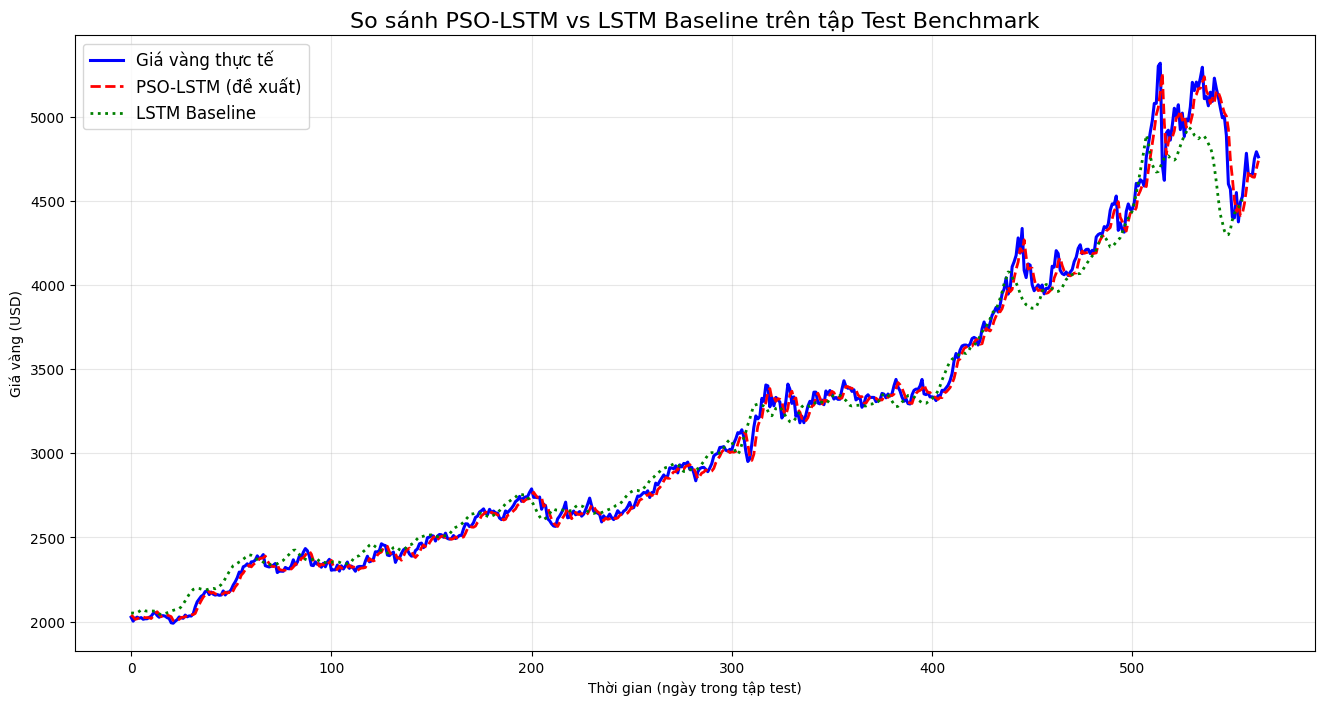

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.plot(y_true, label='Giá vàng thực tế', color='blue', linewidth=2.2)
plt.plot(pred, label='PSO-LSTM (đề xuất)', color='red', linestyle='--', linewidth=2)
plt.plot(pred_base, label='LSTM Baseline', color='green', linestyle=':', linewidth=2)
plt.title('So sánh PSO-LSTM vs LSTM Baseline trên tập Test Benchmark', fontsize=16)
plt.xlabel('Thời gian (ngày trong tập test)')
plt.ylabel('Giá vàng (USD)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()